# Crees que la gente no coopera. Te equivocas.

Te sientas frente a un desconocido. Si los dos renuncian a algo, se donan 400 dólares
para luchar contra el cambio climático. ¿Lo hará el otro? La mayoría de nosotros apuesta
a que **no**. Y la mayoría de nosotros se equivoca.

:::{image} figuras/pixabot.png
:alt: Pixabot mascot
:width: 80px
:align: center
:figclass: pixabot-mascot
:::

---

**Paper:** Andre et al. (2026), *Homo cooperans: Understanding the nature of human cooperation* · *Science*
**DOI:** [10.1126/science.aec9483](https://doi.org/10.1126/science.aec9483)
**Datos:** [Replication Package — bonndata, Universität Bonn](https://doi.org/10.60507/FK2/YIWR09)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-06-07-homo-cooperans-cooperacion-global/notebook.ipynb)

## El juego más simple del mundo

A 101.123 personas en **125 países** les pusieron la misma decisión, con dinero real de por medio:

- **Opción 1:** quédate 100 dólares. Fin.
- **Opción 2:** quédate solo 70 dólares, pero si *la otra persona también* elige el 70,
  se donan 400 dólares para combatir el cambio climático.

Elegir la Opción 2 es cooperar: renuncias a algo seguro apostando a que el otro hará lo mismo.
La muestra viene del Gallup World Poll (2021–2022), así que no son estudiantes de psicología:
es el mundo real, de Taiwán a Tanzania.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
COLOR_DATOS      = '#2563EB'   # Azul CaM — lo real
COLOR_ALERTA     = '#DC2626'   # Rojo — la excepción / el contraste
COLOR_CREENCIA   = '#D97706'   # Ámbar — lo que la gente cree
COLOR_REFERENCIA = '#7C3AED'   # Violeta — correlaciones
FUENTE = 'Fuente: Andre et al. (2026), Science | Datos: bonndata (Univ. Bonn)'

import os, urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Estilo CaM (local -> fallback GitHub raw)
BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# Carga de los 3 CSV agregados (publicados con el paper)
paises     = pd.read_csv('datos/cooperacion_por_pais.csv')
continente = pd.read_csv('datos/cooperacion_por_continente.csv')
trat       = pd.read_csv('datos/efecto_tratamiento.csv')

print(f'Países: {len(paises)}  |  Continentes: {len(continente)}  |  Grupos del experimento: {len(trat)}')
print(f'Cooperación: media {paises.tasa_cooperacion.mean()*100:.1f}%  '
      f'mediana {paises.tasa_cooperacion.median()*100:.1f}%')
print(f'Lo que la gente CREE que coopera: {paises.creencia_cooperacion.mean()*100:.1f}%')

Países: 125  |  Continentes: 5  |  Grupos del experimento: 2
Cooperación: media 72.7%  mediana 75.0%
Lo que la gente CREE que coopera: 44.9%


## Aquí está la brecha.

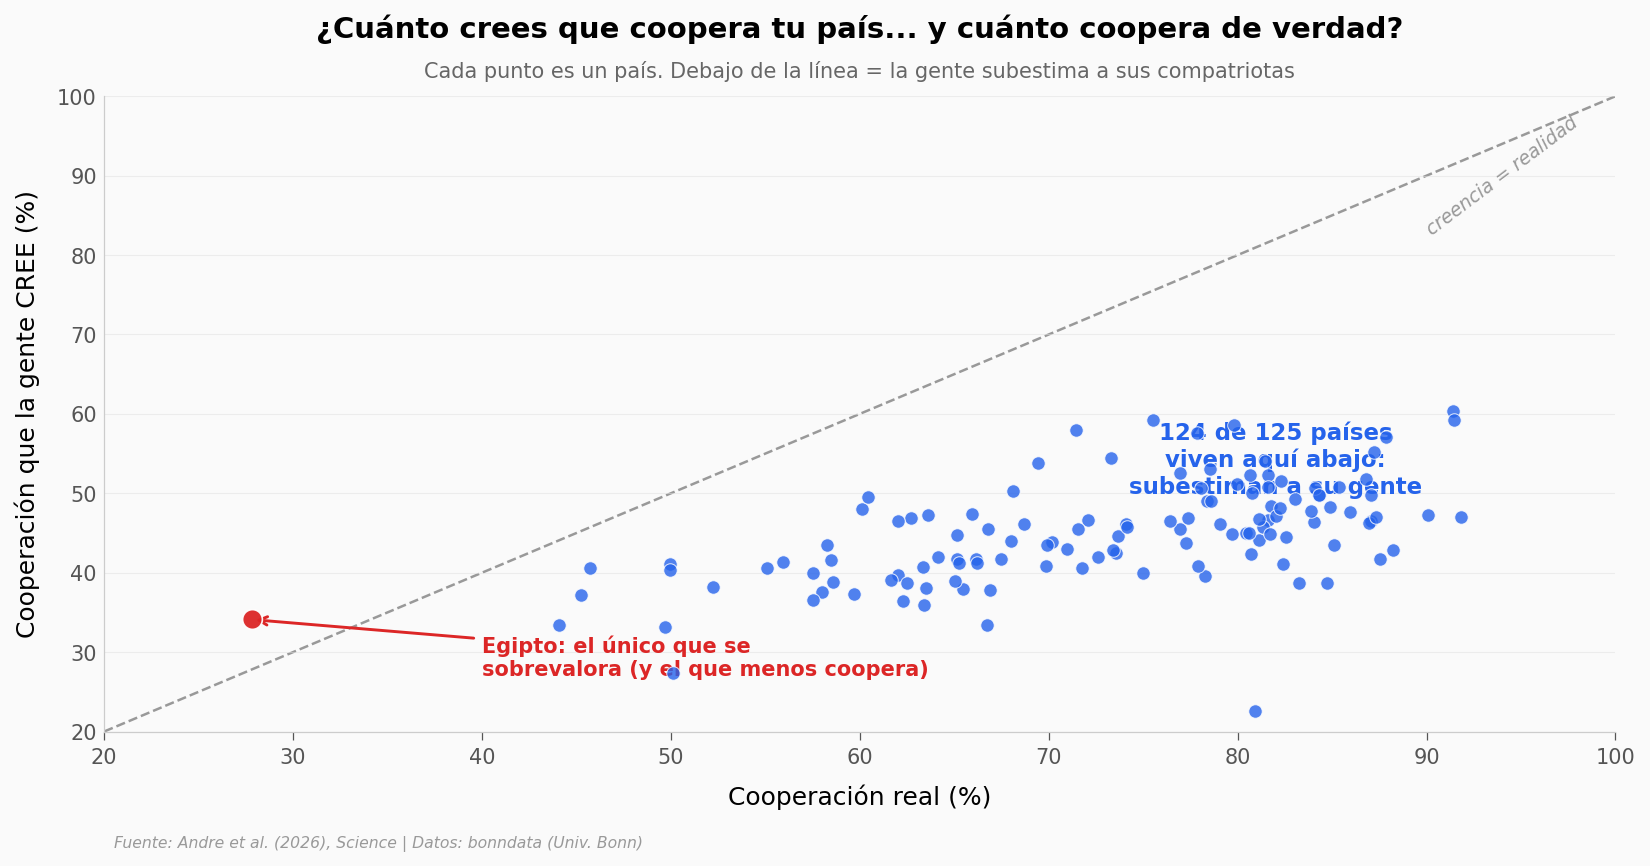

In [2]:
fig, ax = plt.subplots(figsize=(13, 5.5))

real    = paises['tasa_cooperacion'] * 100
creido  = paises['creencia_cooperacion'] * 100
subestima = paises['brecha_percepcion'] > 0

# Diagonal: dónde caería un país que se conoce perfectamente
lim = [20, 100]
ax.plot(lim, lim, color='#999999', linewidth=1.2, linestyle='--', zorder=1)
ax.text(94, 90, 'creencia = realidad', fontsize=9, color='#999999',
        rotation=37, ha='center', va='center', style='italic')

# 124 países que SUBESTIMAN (debajo de la diagonal)
ax.scatter(real[subestima], creido[subestima], color=COLOR_DATOS, s=42,
           alpha=0.80, edgecolors='white', linewidths=0.5, zorder=5)
# La única excepción: Egipto (sobreestima)
ax.scatter(real[~subestima], creido[~subestima], color=COLOR_ALERTA, s=90,
           alpha=0.95, edgecolors='white', linewidths=0.8, zorder=6)
ax.annotate('Egipto: el único que se\nsobrevalora (y el que menos coopera)',
            xy=(27.8, 34.1), xytext=(40, 27),
            fontsize=10, fontweight='bold', color=COLOR_ALERTA,
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.4))
ax.text(82, 50, '124 de 125 países\nviven aquí abajo:\nsubestiman a su gente',
        fontsize=11, color=COLOR_DATOS, fontweight='bold', ha='center')

ax.set_title('¿Cuánto crees que coopera tu país... y cuánto coopera de verdad?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Cada punto es un país. Debajo de la línea = la gente subestima a sus compatriotas',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.set_xlabel('Cooperación real (%)')
ax.set_ylabel('Cooperación que la gente CREE (%)')
ax.set_xlim(20, 100); ax.set_ylim(20, 100)
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/brecha_percepcion.png', dpi=200, bbox_inches='tight')
plt.show()

Casi todos los puntos caen **por debajo** de la línea. Eso significa que en 124 de los 125 países,
la gente cree que sus compatriotas cooperan menos de lo que en realidad cooperan. En promedio, la
diferencia es de **27,8 puntos porcentuales**: creemos que coopera el 45% cuando coopera el 73%.

El caso extremo es Letonia, donde la brecha llega a 58,4 puntos. Y la única excepción del planeta
es Egipto, que se sobrevalora un poco —curiosamente, también es el país que menos coopera (28%).

Las creencias no están desconectadas de la realidad: donde más se coopera, la gente *intuye* que se
coopera más (correlación de rangos ρ = 0,59). Pero esa intuición vive sistemáticamente por debajo de
la verdad. Somos más cooperativos de lo que creemos.

## Pero "la gente" no es igual en todas partes

Ese 73% global esconde un abismo. Veamos quiénes encabezan la lista y quiénes la cierran.

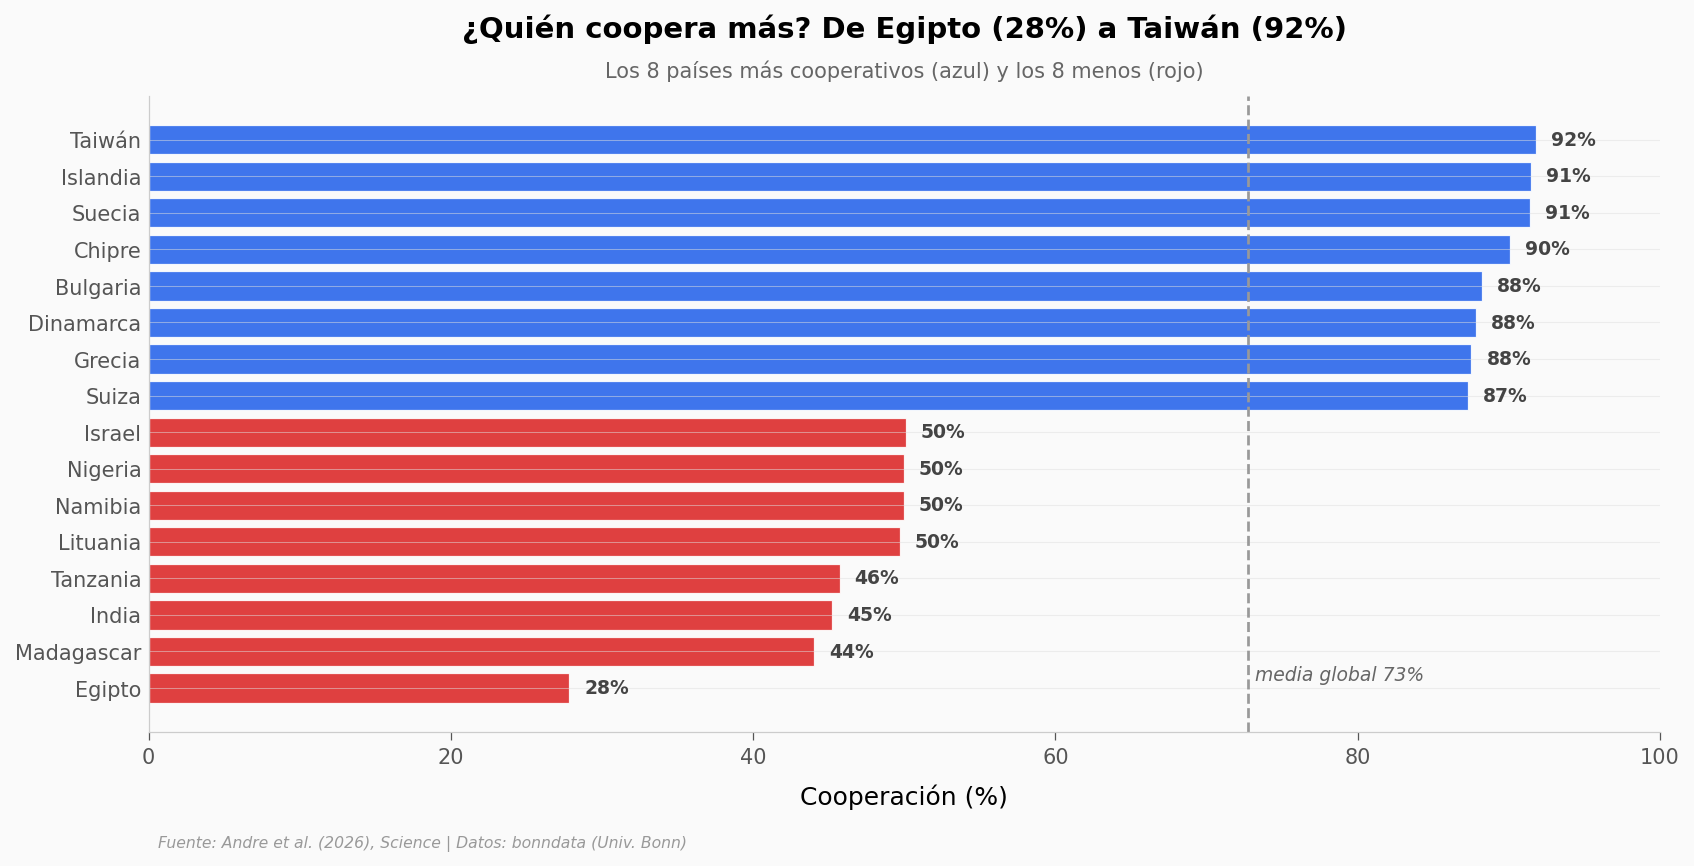

In [3]:
top    = paises.nlargest(8, 'tasa_cooperacion').sort_values('tasa_cooperacion')
bottom = paises.nsmallest(8, 'tasa_cooperacion').sort_values('tasa_cooperacion')
sel = pd.concat([bottom, top])

# Traducir nombres al español para las etiquetas
es = {'Taiwan':'Taiwán','Iceland':'Islandia','Sweden':'Suecia','Cyprus':'Chipre',
      'Bulgaria':'Bulgaria','Denmark':'Dinamarca','Greece':'Grecia','Switzerland':'Suiza',
      'Egypt':'Egipto','Madagascar':'Madagascar','India':'India','Tanzania':'Tanzania',
      'Lithuania':'Lituania','Namibia':'Namibia','Nigeria':'Nigeria','Israel':'Israel'}
nombres = [es.get(p, p) for p in sel['pais']]
valores = sel['tasa_cooperacion'].values * 100
colores = [COLOR_ALERTA if v < 60 else COLOR_DATOS for v in valores]

fig, ax = plt.subplots(figsize=(13, 5.5))
y = np.arange(len(sel))
ax.barh(y, valores, color=colores, alpha=0.88, edgecolor='white', linewidth=0.6)
for yi, v in zip(y, valores):
    ax.text(v + 1, yi, f'{v:.0f}%', va='center', fontsize=9,
            fontweight='bold', color='#444444')
ax.axvline(x=paises.tasa_cooperacion.mean()*100, color='#999999',
           linewidth=1.3, linestyle='--')
ax.text(paises.tasa_cooperacion.mean()*100 + 0.5, 0.2, 'media global 73%',
        fontsize=9, color='#666666', style='italic')

ax.set_yticks(y); ax.set_yticklabels(nombres, fontsize=10)
ax.set_xlabel('Cooperación (%)')
ax.set_xlim(0, 100)
ax.set_title('¿Quién coopera más? De Egipto (28%) a Taiwán (92%)',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Los 8 países más cooperativos (azul) y los 8 menos (rojo)',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/ranking_paises.png', dpi=200, bbox_inches='tight')
plt.show()

## Si el problema es lo que creemos... ¿se puede arreglar?

Aquí el estudio deja de solo *observar* y hace un **experimento**: a la mitad de los participantes,
elegidos al azar, les contaron cuánta gente coopera de verdad antes de decidir. ¿Cambia algo
decirle a la gente que sus vecinos son mejores de lo que pensaban?

Efecto del tratamiento: +0.76 pp  |  z = 2.74  |  p = 0.006


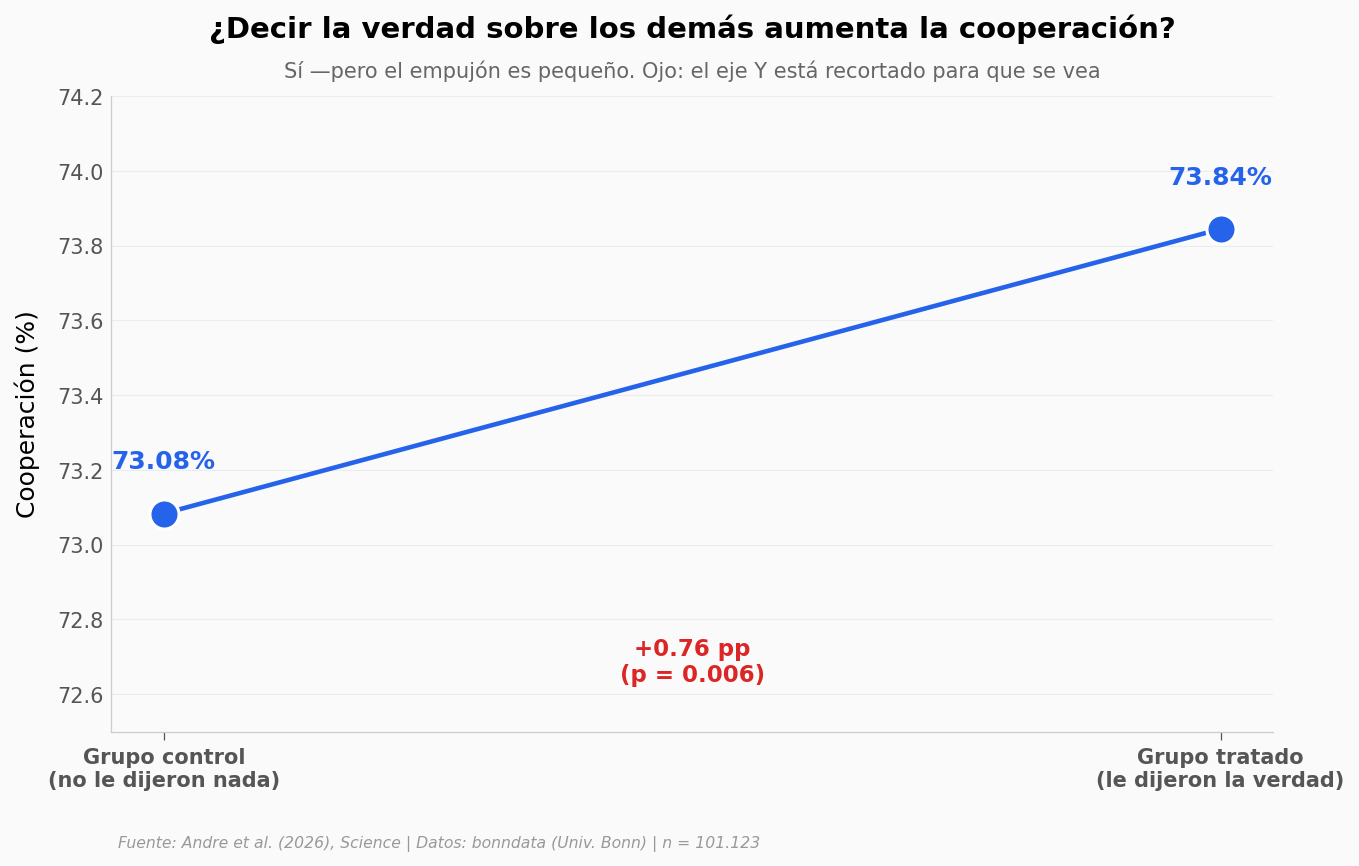

In [4]:
ctrl  = trat[trat['grupo'].str.contains('Control')].iloc[0]
treat = trat[trat['grupo'].str.contains('Tratamiento')].iloc[0]
c_coop, t_coop = ctrl['tasa_cooperacion']*100, treat['tasa_cooperacion']*100
delta = t_coop - c_coop

# Test de dos proporciones (N enorme -> potencia alta pese a efecto pequeño)
n1, n2 = int(ctrl['n']), int(treat['n'])
p_pool = (ctrl['tasa_cooperacion']*n1 + treat['tasa_cooperacion']*n2) / (n1+n2)
se = np.sqrt(p_pool*(1-p_pool)*(1/n1 + 1/n2))
z = (treat['tasa_cooperacion'] - ctrl['tasa_cooperacion']) / se
pval = 2*(1 - stats.norm.cdf(abs(z)))
print(f'Efecto del tratamiento: +{delta:.2f} pp  |  z = {z:.2f}  |  p = {pval:.3f}')

fig, ax = plt.subplots(figsize=(10, 5.5))
x = [0, 1]
ax.plot(x, [c_coop, t_coop], color=COLOR_DATOS, linewidth=2.2,
        marker='o', markersize=14, markeredgecolor='white',
        markeredgewidth=1.5, zorder=5)
for xi, v, lab in zip(x, [c_coop, t_coop], ['Sin info', 'Con info real']):
    ax.text(xi, v + 0.12, f'{v:.2f}%', ha='center', fontsize=12,
            fontweight='bold', color=COLOR_DATOS)
# Anotar el delta
ax.annotate(f'+{delta:.2f} pp\n(p = {pval:.3f})', xy=(0.5, (c_coop+t_coop)/2),
            xytext=(0.5, c_coop - 0.45), ha='center', fontsize=11,
            fontweight='bold', color=COLOR_ALERTA)

ax.set_xticks(x)
ax.set_xticklabels(['Grupo control\n(no le dijeron nada)',
                    'Grupo tratado\n(le dijeron la verdad)'], fontsize=10, fontweight='bold')
ax.set_ylabel('Cooperación (%)')
ax.set_ylim(72.5, 74.2)  # eje recortado: el efecto es real pero pequeño
ax.set_title('¿Decir la verdad sobre los demás aumenta la cooperación?',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Sí —pero el empujón es pequeño. Ojo: el eje Y está recortado para que se vea',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE + ' | n = 101.123', fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/efecto_tratamiento.png', dpi=200, bbox_inches='tight')
plt.show()

## ¿Qué tan generalizada es la brecha?

Un empujón de menos de un punto suena modesto. Pero recuerda contra qué pelea: una brecha de
percepción que existe en *casi todos los países a la vez*. Veamos su forma.

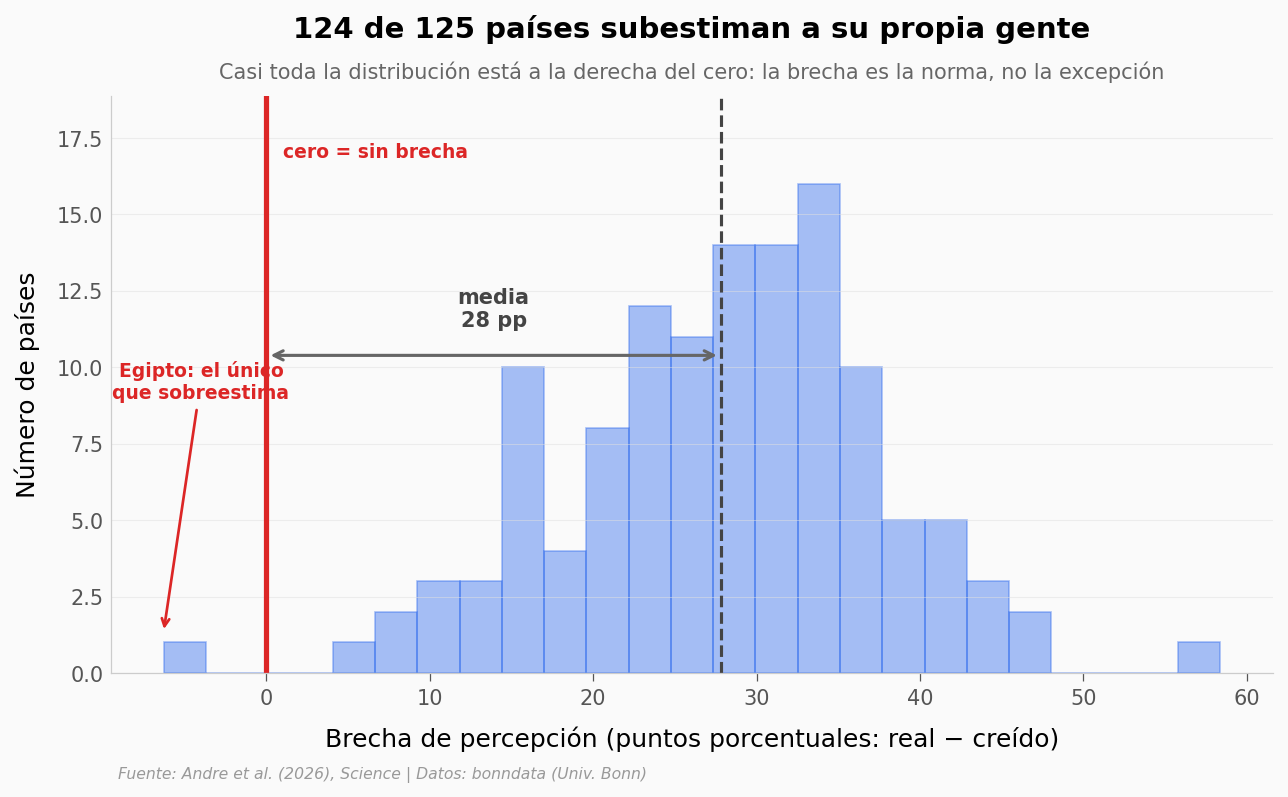

In [5]:
brecha_pp = paises['brecha_percepcion'].values * 100
media_brecha = brecha_pp.mean()

fig, ax = plt.subplots(figsize=(10, 5))
n, bins, patches = ax.hist(brecha_pp, bins=25, color=COLOR_DATOS, alpha=0.40,
                           edgecolor=COLOR_DATOS, linewidth=0.8)
y_max = n.max() * 1.18
ax.set_ylim(0, y_max)

# Línea en cero (sin brecha) y en la media
ax.axvline(x=0, color=COLOR_ALERTA, linewidth=2.5)
ax.text(1, y_max*0.92, 'cero = sin brecha', fontsize=9,
        color=COLOR_ALERTA, fontweight='bold', va='top')
# Egipto es la única barra a la IZQUIERDA del cero (sobreestima)
ax.annotate('Egipto: el único\nque sobreestima', xy=(-6.3, 1.3), xytext=(-4, 9),
            fontsize=9, color=COLOR_ALERTA, fontweight='bold', ha='center',
            arrowprops=dict(arrowstyle='->', color=COLOR_ALERTA, lw=1.3))
ax.axvline(x=media_brecha, color='#444444', linewidth=1.5, linestyle='--')
ax.annotate('', xy=(media_brecha, y_max*0.55), xytext=(0, y_max*0.55),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text(media_brecha/2, y_max*0.60, f'media\n{media_brecha:.0f} pp',
        ha='center', fontsize=10, color='#444444', fontweight='bold')

ax.set_xlabel('Brecha de percepción (puntos porcentuales: real − creído)')
ax.set_ylabel('Número de países')
ax.set_title('124 de 125 países subestiman a su propia gente',
             fontsize=14, fontweight='bold', pad=28)
ax.text(0.5, 1.03, 'Casi toda la distribución está a la derecha del cero: la brecha es la norma, no la excepción',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/histograma_brecha.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| ~73% de la gente coopera | ✅ | Media de 125 países = 72,7% (mediana 75,0%, rango intercuartílico 65–82%). El abstract dice "cerca de dos tercios"; ponderado por población baja a ~73% por países grandes de baja cooperación (India 45%) |
| La gente subestima la cooperación ajena | ✅ | 124 de 125 países (99,2%) creen menos de lo real. Brecha media 27,8 pp. Única excepción: Egipto |
| Las creencias siguen a la realidad | ✅ | Spearman ρ = 0,59 (p < 0,0001). La realidad no es normal (Shapiro p < 0,001) → se reporta Spearman, no Pearson |
| La norma social y las preferencias se asocian con cooperar | ⚠️ | Correlacional, **no causal**: paciencia ρ = 0,48, riesgo ρ = 0,37, norma social ρ = 0,33. El altruismo NO correlaciona (ρ = −0,11, p = 0,23) |
| Informar sobre la cooperación real *aumenta* la cooperación | ✅ | Único claim **causal** (asignación aleatoria): +0,76 pp, z = 2,74, p = 0,006. Efecto pequeño (Cohen's h = 0,02) pero significativo por el N enorme |

> **Limitaciones:** (1) Salvo el experimento de información, todo es **observacional** — los determinantes se *asocian* con cooperar, no la *causan*. (2) Cooperación medida con UN juego de un solo turno; no captura cooperación repetida ni en grupos. (3) Los agregados país-nivel publicados con el paper ocultan la variación individual. (4) El efecto causal del tratamiento (~0,8 pp) es real pero modesto: corregir la percepción ayuda, no transforma.

## Ahora tú

Los datos están cargados. Tres preguntas para hurgar:

1. **¿Qué pesa más, querer cooperar o creer que los demás lo harán?** El DataFrame `paises` trae
   columnas de preferencias (`altruismo_z`, `riesgo_z`, `paciencia_z`) y de norma social. Prueba
   `stats.spearmanr(paises['paciencia_z'], paises['tasa_cooperacion'])` y compáralo con el altruismo.
   ¿Te sorprende cuál gana?

2. **¿Tu país está sobre o bajo la diagonal?** Filtra `paises[paises['pais'] == 'Colombia']`
   (o el que quieras) y mira su `brecha_percepcion`. ¿Cuánto subestima su propia gente?

3. **¿La brecha es mayor donde más se coopera?** Cruza `tasa_cooperacion` con `brecha_percepcion`.
   ¿Los países muy cooperativos también son los que más se subestiman?

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿Qué "preferencia" predice mejor la cooperación de un país?
# (Ojo: correlación, NO causa. Son datos observacionales.)

predictores = {
    'Paciencia':    'paciencia_z',
    'Aversión riesgo': 'riesgo_z',
    'Norma social': 'norma_social',
    'Altruismo':    'altruismo_z',
}
print('Correlación de rangos (Spearman) con la cooperación real:\n')
for nombre, col in predictores.items():
    rho, p = stats.spearmanr(paises[col], paises['tasa_cooperacion'])
    sig = '✓ significativa' if p < 0.05 else '✗ no significativa'
    print(f'  {nombre:16s} ρ = {rho:+.2f}   (p = {p:.4f})  {sig}')

print('\nSorpresa: el altruismo declarado NO es el que más predice cooperar.')
print('Lo que mejor acompaña a la cooperación es la paciencia y la norma social.')

Correlación de rangos (Spearman) con la cooperación real:

  Paciencia        ρ = +0.48   (p = 0.0000)  ✓ significativa
  Aversión riesgo  ρ = +0.37   (p = 0.0000)  ✓ significativa
  Norma social     ρ = +0.33   (p = 0.0002)  ✓ significativa
  Altruismo        ρ = -0.11   (p = 0.2250)  ✗ no significativa

Sorpresa: el altruismo declarado NO es el que más predice cooperar.
Lo que mejor acompaña a la cooperación es la paciencia y la norma social.


---

## Fuentes

**Paper**: [Homo cooperans: Understanding the nature of human cooperation](https://doi.org/10.1126/science.aec9483)  
*Science, 2026-06-04*

**Datos**: [Replication Package for 'Homo Cooperans: Understanding the Nature of Human Cooperation' (Global Cooperation Dataset)](https://doi.org/10.60507/FK2/YIWR09)  
*bonndata (Universität Bonn), replication package*

*11 afirmaciones del notebook verificadas contra estas fuentes*

---

*Notebook reproducible de [Ciencia a Mordiscos](https://cienciaamordiscos.com) ·
[Repositorio del Lab](https://github.com/Ciencia-a-Mordiscos/lab) ·
Datos bajo licencia del [Replication Package](https://doi.org/10.60507/FK2/YIWR09)*